This makes predictions for elections based on features such as polling lead and days until next election

In [130]:
import pandas as pd
import numpy as np
import plotly.express as px
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error
from utils.model_utils import plot_basic_decision_tree

In [131]:
pdf_all = pd.read_csv("data/intermediate/national_data.csv").query(" ~Conservative_election.isna()")


In [ ]:
# Manually add a row for 2029-07-04 with Election_Flag = 1
#These predictions are arbitrarily chosen
manual_row = {"Date": "2029-07-04", "Election_Flag": 1,  "Conservative_election": 375,
    "Labour_election": 200,
    "Liberal Democrats_election": 30, "Incumbent": "Conservative_election", "Incumbent_Start_Date": "2029-07-04", "Incumbent_Duration_Days": 0
}
pdf_all = pd.concat([pdf_all, pd.DataFrame([manual_row])], ignore_index=True)

In [ ]:
def define_next_election_results(pdf_all):


    """ For each row in the dataframe, define the results of the next election."""

    election_cols = [
        "Conservative_election",
        "Labour_election",
        "Liberal Democrats_election",
    ]

    next_election_cols = [f"{col}_next" for col in election_cols]

    pdf_all[next_election_cols] = pdf_all[election_cols]

    pdf_all.loc[pdf_all["Election_Flag"] != 1, next_election_cols] = np.nan

    pdf_all[next_election_cols] = pdf_all[next_election_cols].bfill()

    return pdf_all, 


In [ ]:
pdf_all, next_election_cols = define_next_election_results(pdf_all)

In [140]:
# Update next election info only for rows after 2024-07-03
cutoff_date = pd.to_datetime("2024-07-04")
next_election_date = pd.to_datetime("2029-07-04")

pdf_all["Date"] = pd.to_datetime(pdf_all["Date"])

pdf_all["Conservative_election_next"] = np.where(
    pdf_all["Date"] > cutoff_date, 375, pdf_all["Conservative_election_next"]
)
pdf_all["Labour_election_next"] = np.where(
    pdf_all["Date"] > cutoff_date, 200, pdf_all["Labour_election_next"]
)
pdf_all["Liberal Democrats_election_next"] = np.where(
    pdf_all["Date"] > cutoff_date, 30, pdf_all["Liberal Democrats_election_next"]
)
pdf_all["Days_Until_Next_Election"] = np.where(
    pdf_all["Date"] > cutoff_date,
    (next_election_date - pdf_all["Date"]).dt.days,
    pdf_all["Days_Until_Next_Election"] if "Days_Until_Next_Election" in pdf_all else np.nan
)

In [141]:
pdf_all["Incumbent_Next"] = pdf_all[next_election_cols].idxmax(axis=1)

In [142]:
# Conservative polling lead
pdf_all["Conservative_Lead_Next"] = pdf_all["Conservative_election_next"] - pdf_all["Labour_election_next"]

# Incumbent_Win logic:
# If Conservatives are incumbent → use lead
# If Labour is incumbent → negative of Conservative lead
pdf_all["Incumbent_Win_Next"] = np.where(
    pdf_all["Incumbent"] == "Conservative_election",
    pdf_all["Conservative_Lead_Next"],
    -pdf_all["Conservative_Lead_Next"],
)

In [144]:
target = "Incumbent_Win_Next"
features = ["Incumbent_Duration_Days", "Incumbent_Win", "Days_Until_Next_Election" 
]

In [145]:
print(pdf_all.agg({"Date":["min","max"]}))

          Date
min 1955-05-26
max 2029-07-04


In [146]:
pdf_all_filtered = pdf_all[[target] + features + ["Date"]].dropna(subset=[target] + features)

In [147]:
print(pdf_all_filtered.agg({"Date":["min","max"]}))

          Date
min 1955-07-13
max 2025-12-03


In [148]:
# Prepare X and y
X = pdf_all_filtered[features]
X = sm.add_constant(X, has_constant="add")
y = pdf_all_filtered[target]

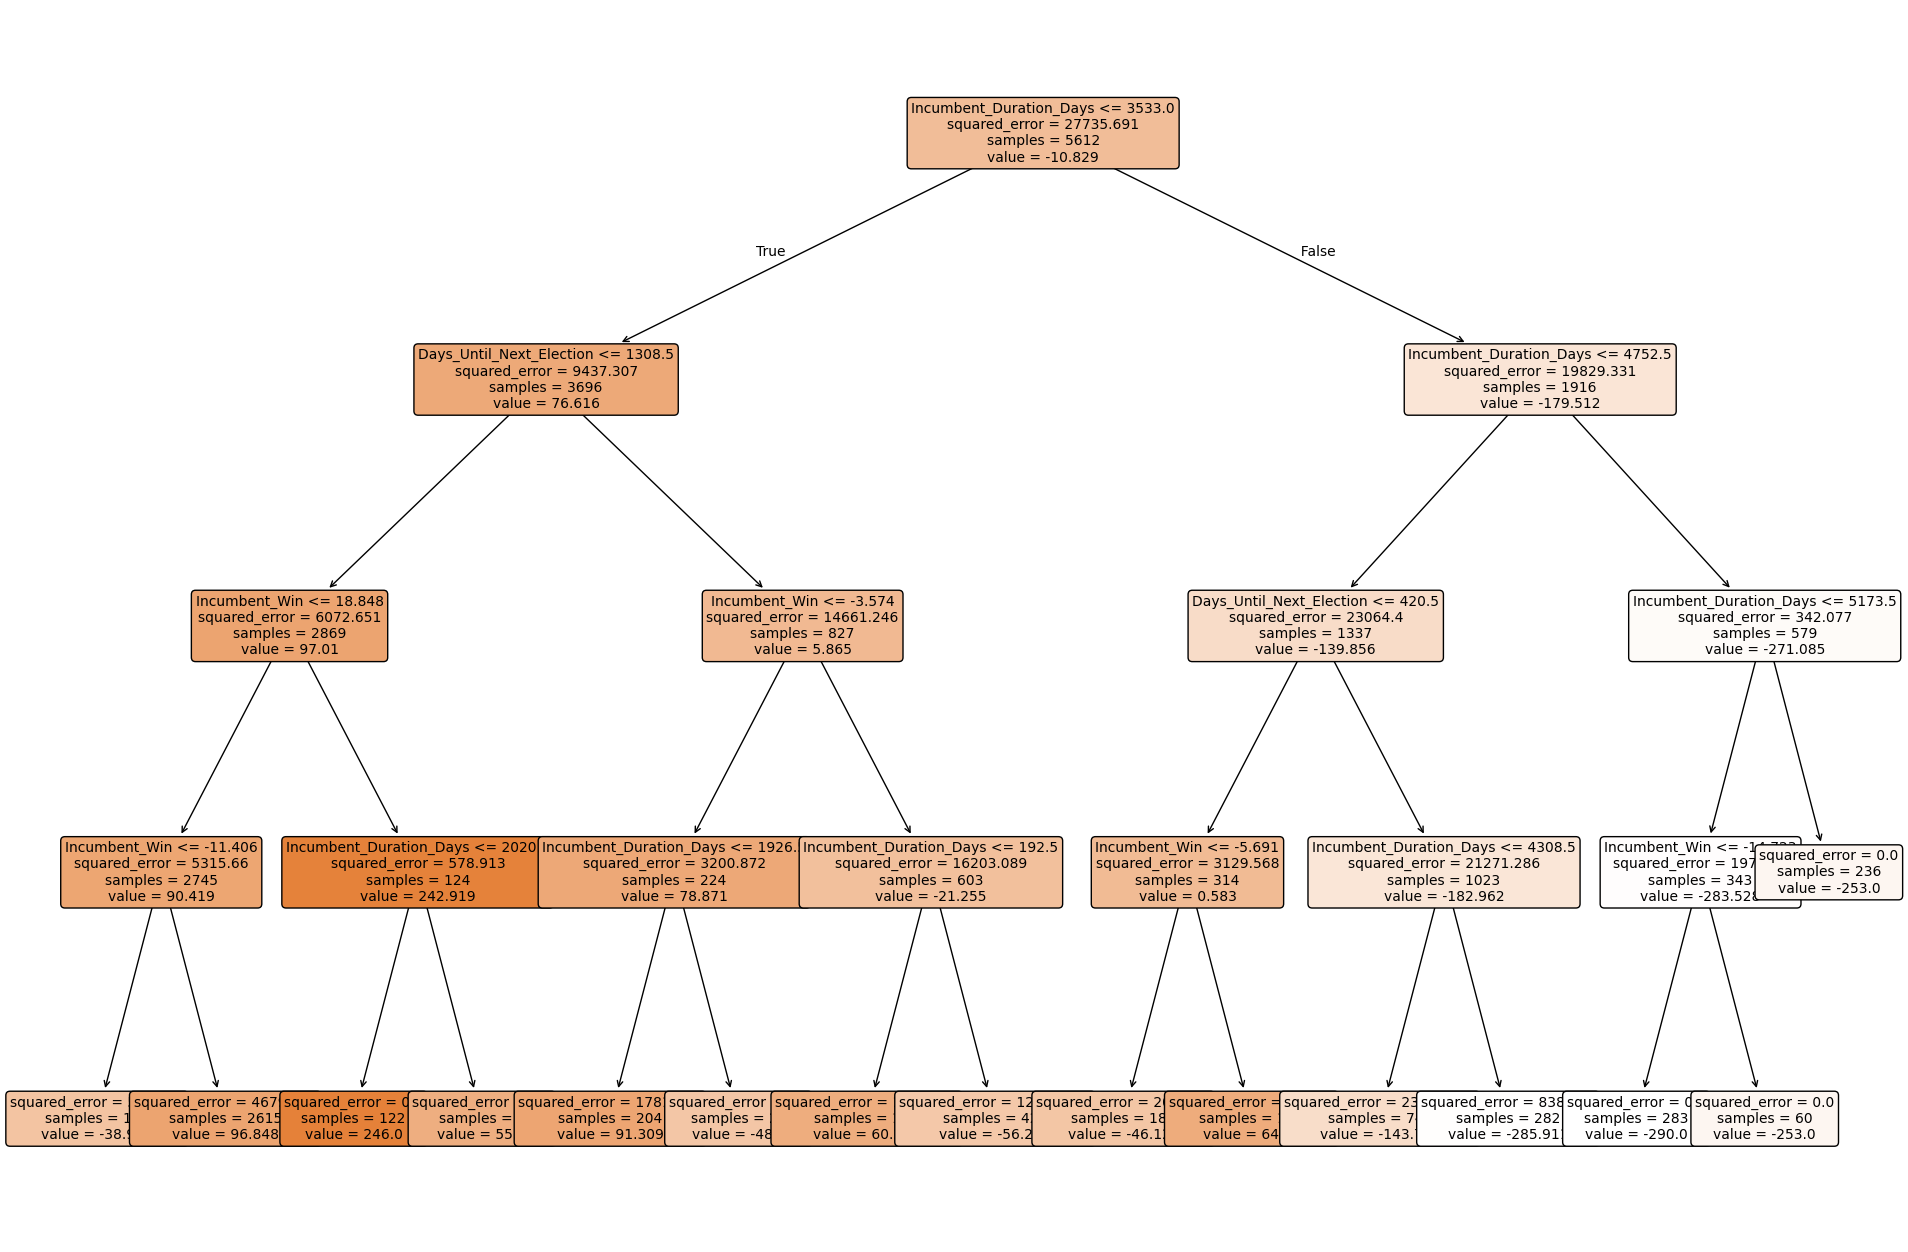

In [149]:
plot_basic_decision_tree(pdf_all_filtered, features, target, max_depth=4)

In [ ]:
# Fit regression
model = sm.OLS(y, X).fit()

predictions = model.predict(X)
results_df = pd.DataFrame(
    {"actual": y, "predicted": predictions, "residual": y - predictions}
).round(2)

results_df["Date"] = pdf_all_filtered["Date"].values

mae = mean_absolute_error(y, predictions)

print(model.summary())

px.scatter(
    results_df,
    x="actual",
    y="predicted",
    trendline="ols",
    title=f"Actual vs Predicted (MAE: {mae:.2f})",
    hover_data=["Date"],
)


                            OLS Regression Results                            
Dep. Variable:     Incumbent_Win_Next   R-squared:                       0.553
Model:                            OLS   Adj. R-squared:                  0.553
Method:                 Least Squares   F-statistic:                     2313.
Date:                Mon, 05 Jan 2026   Prob (F-statistic):               0.00
Time:                        14:50:37   Log-Likelihood:                -34410.
No. Observations:                5612   AIC:                         6.883e+04
Df Residuals:                    5608   BIC:                         6.885e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [153]:
px.line(results_df, x="Date", y=["actual", "predicted", "residual"])